# Agreement between models

For every ground-truth cell: how many of the 7 models detected it (`k`, IoU >= 0.5)? Part 1 asks how well each model
segments the cells it finds as a function of `k`. Part 2 asks what is special about the cells few models find
("Rare", k <= 2) compared with cells every model finds ("Consensus", k = 7). Max-Projection, selected arm.

The matching step loads every GT and prediction image, so it takes a few minutes. It runs here, in the notebook.

In [1]:
import sys
from pathlib import Path

BENCH_DIR = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if p.name == "bench")
sys.path.insert(0, str(BENCH_DIR))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage.io
import skimage.measure
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

from figures.utils import holm_adjust, stars
from import_util import data_path
from validation.consolidate import DATASETS, load, scores_dir
from validation.multi_model import IOU_THR, collect_cell_records, pred_path_for
from validation.shape_level import get_compactness

matplotlib.rcParams["pdf.fonttype"] = 42
EXPORT_DIR = BENCH_DIR / "figures" / "export"

MODEL_ORDER = ["Cellpose", "InstanSeg", "Stardist", "Mesmer", "Dist U-Net", "Cellpose-SAM", "MicroSAM"]
N_MODELS = len(MODEL_ORDER)
COLORS = {  # seaborn colorblind palette
    "Cellpose": "#0173B2", "InstanSeg": "#DE8F05", "Stardist": "#029E73", "Mesmer": "#D55E00",
    "Dist U-Net": "#CC78BC", "Cellpose-SAM": "#CA9161", "MicroSAM": "#949494",
}

RARE_K_MAX = 2  # "Rare" cells: found by at most this many models
BUCKET_ORDER = ["Rare", "Consensus"]
BUCKET_LABEL = {"Rare": f"Rare (k<={RARE_K_MAX})", "Consensus": f"Consensus (k=={N_MODELS})"}
BUCKET_COLOR = {"Rare": "#D55E00", "Consensus": "#0173B2"}
SHAPES = ["Eccentricity", "Solidity", "Compactness"]  # GT shape of each cell

## Match every model's prediction to the GT cells

One row per GT cell that at least one model detected: its image, `k`, its GT shape, and for each model that detected
it the IoU and Dice of the match (empty otherwise).

In [2]:
runs = load()  # one row per test image of every run
runs = runs[(runs["Modality"] == "MaxProj") & (runs["Arm"] == "selected") & runs["Model"].isin(MODEL_ORDER)]
assert runs.groupby("Model")["ID"].apply(frozenset).nunique() == 1, "models were scored on different images"

images = runs[["Dataset", "Fold", "ID"]].drop_duplicates()
run_of = runs.drop_duplicates(["Model", "Dataset", "Fold"]).set_index(["Model", "Dataset", "Fold"])["Run"]


def gt_cell_shapes(label_img):
    """{cell index: shape}, with cell index = region label - 1 in the relabeled GT mask."""
    relabeled = skimage.measure.label(label_img, background=0)
    return {
        p.label - 1: {
            "Eccentricity": p.eccentricity, "Solidity": p.solidity,
            "Compactness": get_compactness(p) if p.perimeter > 50 else np.nan,  # same noise gate as ShapeLevelMetrics
        }
        for p in skimage.measure.regionprops(relabeled)
    }


rows = []
for (dataset, fold), group in images.groupby(["Dataset", "Fold"], sort=False):
    label_paths = [str(data_path(p)) for p in group["ID"]]
    pred_paths = {
        model: [pred_path_for(str(scores_dir(model, dataset)), run_of[(model, dataset, fold)], fold, lp) for lp in label_paths]
        for model in MODEL_ORDER
    }
    shapes = {lp: gt_cell_shapes(skimage.io.imread(lp)) for lp in label_paths}

    for record in collect_cell_records(label_paths, pred_paths, iou_thr=IOU_THR):
        image_id = label_paths[record.image_idx]
        row = {"Dataset": dataset, "Fold": fold, "ID": image_id, "gt_idx": record.gt_idx, "k": record.k,
               **shapes[image_id][record.gt_idx]}
        for model, (iou, dice) in record.scores.items():
            row[f"iou_{model}"], row[f"dice_{model}"] = iou, dice
        rows.append(row)
    print(f"{dataset} fold {fold}: {len(label_paths)} images")

cells = pd.DataFrame(rows)
print(f"{len(cells)} GT cells detected by at least one model")
cells.head()

Vectra fold 0: 27 images
Vectra fold 1: 27 images
Vectra fold 2: 26 images
Vectra fold 3: 26 images
Vectra fold 4: 26 images
CODEX fold 0: 2 images
CODEX fold 1: 2 images
CODEX fold 2: 2 images
CODEX fold 3: 2 images
CODEX fold 4: 2 images
MACSima fold 0: 18 images
MACSima fold 1: 18 images
MACSima fold 2: 18 images
MACSima fold 3: 18 images
MACSima fold 4: 17 images
Zeiss fold 0: 4 images
Zeiss fold 1: 4 images
Zeiss fold 2: 4 images
Zeiss fold 3: 4 images
Zeiss fold 4: 3 images
79584 GT cells detected by at least one model


,Dataset,Fold,ID,gt_idx,k,Eccentricity,Solidity,Compactness,iou_Cellpose,dice_Cellpose,...,iou_Stardist,dice_Stardist,iou_Mesmer,dice_Mesmer,iou_Cellpose-SAM,dice_Cellpose-SAM,iou_MicroSAM,dice_MicroSAM,iou_Dist U-Net,dice_Dist U-Net
0,Vectra,0,/home/benjaminba/Documents/Project_data/Multip...,0,6,0.923921,0.940718,0.623017,0.948304,0.973466,...,0.849673,0.918728,0.669935,0.802348,0.908360,0.951980,0.915470,0.955870,NaN,NaN
1,Vectra,0,/home/benjaminba/Documents/Project_data/Multip...,115,3,0.753080,0.897959,NaN,0.833333,0.909091,...,0.587302,0.740000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Vectra,0,/home/benjaminba/Documents/Project_data/Multip...,88,7,0.728279,0.954606,0.834877,0.902850,0.948945,...,0.861386,0.925532,0.875000,0.933333,0.835358,0.910294,0.846883,0.917095,0.915416,0.955840
3,Vectra,0,/home/benjaminba/Documents/Project_data/Multip...,193,7,0.576169,0.949202,0.848329,0.918033,0.957265,...,0.664212,0.798230,0.704718,0.826786,0.753866,0.859662,0.691603,0.817690,0.677370,0.807657
4,Vectra,0,/home/benjaminba/Documents/Project_data/Multip...,244,7,0.774751,0.930175,0.851728,0.871671,0.931436,...,0.800000,0.888889,0.815085,0.898123,0.684755,0.812883,0.753149,0.859195,0.776903,0.874446


## Quality against agreement level

For each `N`, only the cells found by exactly `N` models; each model's mean mIoU over those of them it found.
Top: mIoU per model. Bottom: how many cells there are at each level.

In [3]:
rows = []
for n in range(1, N_MODELS + 1):
    at_n = cells[cells["k"] == n]
    for model in MODEL_ORDER:
        iou, dice = at_n[f"iou_{model}"].dropna(), at_n[f"dice_{model}"].dropna()
        if iou.empty:
            continue
        rows.append({
            "N": n, "model": model, "n": len(iou),
            "mIoU_mean": iou.mean(), "mIoU_ci95": 1.96 * iou.std() / np.sqrt(len(iou)) if len(iou) > 1 else 0.0,
            "mDICE_mean": dice.mean(), "mDICE_ci95": 1.96 * dice.std() / np.sqrt(len(dice)) if len(dice) > 1 else 0.0,
        })
by_model = pd.DataFrame(rows)
by_model.to_csv(EXPORT_DIR / "Reviewer_Agreement_by_model_table.csv", index=False)
by_model.head(12)

,N,model,n,mIoU_mean,mIoU_ci95,mDICE_mean,mDICE_ci95
0,1,Cellpose,1261,0.575262,0.006911,0.722051,0.005832
1,1,InstanSeg,1396,0.600718,0.006403,0.743015,0.005231
2,1,Stardist,1185,0.553460,0.006237,0.706010,0.005320
3,1,Mesmer,966,0.541290,0.008253,0.692540,0.007377
4,1,Dist U-Net,392,0.531196,0.014560,0.681554,0.012770
5,1,Cellpose-SAM,466,0.558471,0.012392,0.706627,0.010540
6,1,MicroSAM,436,0.548381,0.013198,0.697461,0.011340
7,2,Cellpose,2686,0.603200,0.004650,0.744889,0.003779
8,2,InstanSeg,2609,0.622166,0.004708,0.759772,0.003734
9,2,Stardist,2065,0.571364,0.004658,0.721073,0.003880


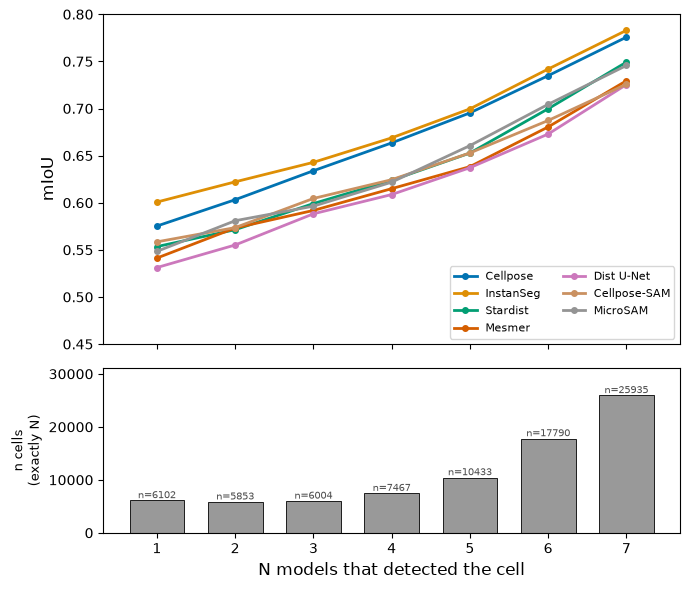

In [4]:
fig, (ax_score, ax_hist) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

for model in MODEL_ORDER:
    sub = by_model[by_model["model"] == model].sort_values("N")
    ax_score.plot(sub["N"], sub["mIoU_mean"], color=COLORS[model], linewidth=2, marker="o", markersize=4, label=model)
ax_score.set_ylabel("mIoU", fontsize=12)
ax_score.set_ylim(0.45, 0.8)
ax_score.legend(loc="lower right", fontsize=8, ncol=2)

k_counts = cells["k"].value_counts().reindex(range(1, N_MODELS + 1), fill_value=0)
bars = ax_hist.bar(k_counts.index, k_counts.values, color="0.6", edgecolor="black", linewidth=0.6, width=0.7)
for bar, count in zip(bars, k_counts.values):
    ax_hist.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"n={count}",
                 ha="center", va="bottom", fontsize=7, color="0.3")
ax_hist.set_xlabel("N models that detected the cell", fontsize=12)
ax_hist.set_ylabel("n cells\n(exactly N)", fontsize=9)
ax_hist.set_xticks(range(1, N_MODELS + 1))
ax_hist.set_ylim(top=k_counts.max() * 1.2)

fig.tight_layout()
fig.savefig(EXPORT_DIR / "Reviewer_Agreement_ByModel.pdf", bbox_inches="tight")

## Who finds which cells

For each agreement level `k`, how many of its cells each model accounts for.

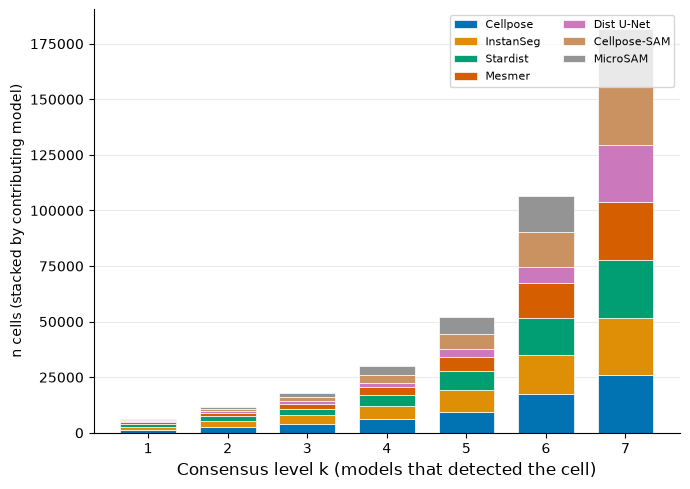

In [5]:
ks = list(range(1, N_MODELS + 1))
fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(ks))
for model in MODEL_ORDER:
    counts = np.array([(cells.loc[cells["k"] == k, f"iou_{model}"].notna()).sum() for k in ks])
    ax.bar(ks, counts, bottom=bottom, color=COLORS[model], edgecolor="white", linewidth=0.5, width=0.7, label=model)
    bottom += counts

ax.set_xlabel("Consensus level k (models that detected the cell)", fontsize=12)
ax.set_ylabel("n cells (stacked by contributing model)", fontsize=10)
ax.set_xticks(ks)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "Reviewer_Agreement_ConsensusByModel.pdf", bbox_inches="tight")

## What is special about hard-to-segment cells?

GT shape of Rare cells (found by at most 2 of the 7 models) vs. Consensus cells (found by all 7); cells in between are
left out. Split violins: left half Rare, right half Consensus. The tests treat cells as independent samples, although
many cells share an image; the effect size (rank-biserial r, +1 = Rare cells are all smaller than Consensus cells,
-1 the reverse) is the more informative number.

In [6]:
cells["bucket"] = None
cells.loc[cells["k"] <= RARE_K_MAX, "bucket"] = "Rare"
cells.loc[cells["k"] == N_MODELS, "bucket"] = "Consensus"
hard = cells.dropna(subset=["bucket"])

print(hard.groupby(["Dataset", "bucket"]).size().unstack())

bucket   Consensus  Rare
Dataset                 
CODEX         1887   660
MACSima       3370  1098
Vectra       15831  8766
Zeiss         4847  1431


In [7]:
def plot_split_violin(data, metric, ax, x=None, order=None):
    """Split violin: left half = Rare, right half = Consensus, one pair per x category
    (or a single pair if `x` is None, for the pooled view)."""
    sns.violinplot(data=data, x=x, y=metric, hue="bucket", order=order, hue_order=BUCKET_ORDER,
                   palette=BUCKET_COLOR, split=True, inner="quart", linewidth=1, cut=0, legend=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def compare_buckets(data, metric):
    """Mann-Whitney U, Rare vs. Consensus, with the rank-biserial effect size."""
    rare = data.loc[data["bucket"] == "Rare", metric].dropna()
    consensus = data.loc[data["bucket"] == "Consensus", metric].dropna()
    u, p = mannwhitneyu(rare, consensus, alternative="two-sided")
    return {"n_rare": len(rare), "n_consensus": len(consensus),
            "rare_median": rare.median(), "consensus_median": consensus.median(),
            "rank_biserial_r": 1 - 2 * u / (len(rare) * len(consensus)), "p_raw": p}


def add_holm(table):
    table["p_holm"] = holm_adjust(table["p_raw"].values)
    table["sig"] = table["p_holm"].apply(stars)
    return table


legend_handles = [Patch(facecolor=BUCKET_COLOR[b], label=BUCKET_LABEL[b]) for b in BUCKET_ORDER]

### By dataset

,metric,Dataset,n_rare,n_consensus,rare_median,consensus_median,rank_biserial_r,p_raw,p_holm,sig
0,Eccentricity,Vectra,8766,15831,0.790382,0.705377,-0.311994,0.000000e+00,0.000000e+00,***
1,Eccentricity,CODEX,660,1887,0.768317,0.674897,-0.344735,8.670015e-40,2.601005e-39,***
2,Eccentricity,MACSima,1098,3370,0.814443,0.701256,-0.419748,3.529111e-97,1.764556e-96,***
3,Eccentricity,Zeiss,1431,4847,0.823679,0.704787,-0.437439,6.319985e-140,4.423989e-139,***
4,Solidity,Vectra,8766,15831,0.907407,0.930403,0.313893,0.000000e+00,0.000000e+00,***
5,Solidity,CODEX,660,1887,0.904972,0.922509,0.269079,6.773710e-25,6.773710e-25,***
6,Solidity,MACSima,1098,3370,0.907350,0.929800,0.262683,3.662935e-39,7.325869e-39,***
7,Solidity,Zeiss,1431,4847,0.897690,0.933333,0.443958,4.565291e-144,3.652233e-143,***
8,Compactness,Vectra,4118,13315,0.705907,0.808951,0.495073,0.000000e+00,0.000000e+00,***
9,Compactness,CODEX,355,1799,0.728499,0.810523,0.446248,2.141494e-40,8.565976e-40,***


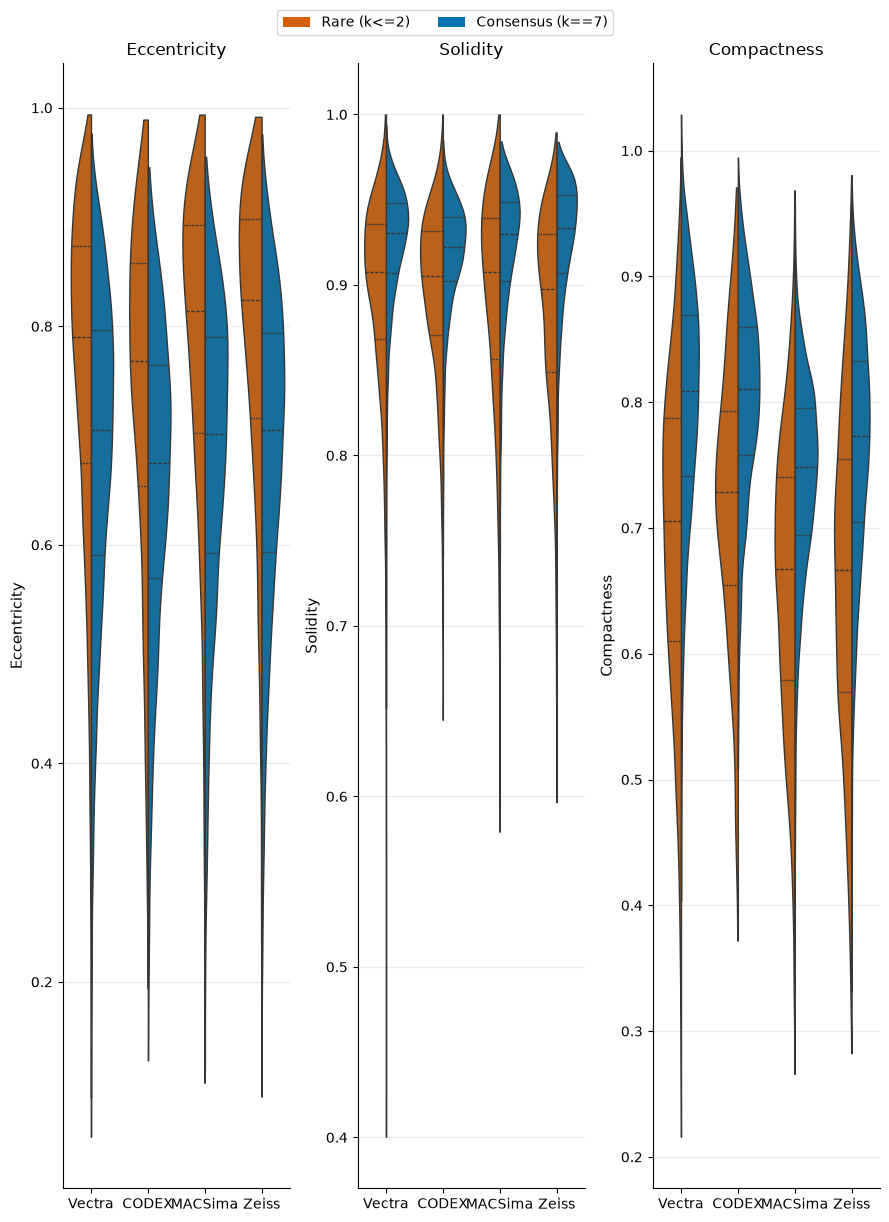

In [8]:
fig, axs = plt.subplots(1, len(SHAPES), figsize=(9, 12))
for ax, metric in zip(axs, SHAPES):
    plot_split_violin(hard, metric, ax, x="Dataset", order=DATASETS)
    ax.set_title(metric, fontsize=12)
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "Reviewer_Agreement_HardCellShape_ByDataset.pdf", bbox_inches="tight")

by_dataset_stats = add_holm(pd.DataFrame([
    {"metric": metric, "Dataset": dataset, **compare_buckets(hard[hard["Dataset"] == dataset], metric)}
    for metric in SHAPES for dataset in DATASETS
]))
by_dataset_stats.to_csv(EXPORT_DIR / "Reviewer_Agreement_HardCellShape_stats.csv", index=False)
by_dataset_stats

### Pooled over datasets

,metric,n_rare,n_consensus,rare_median,consensus_median,rank_biserial_r,p_raw,p_holm,sig
0,Eccentricity,11955,25935,0.794739,0.702157,-0.341304,0.0,0.0,***
1,Solidity,11955,25935,0.906250,0.930233,0.321421,0.0,0.0,***
2,Compactness,6909,23330,0.693095,0.791302,0.473975,0.0,0.0,***


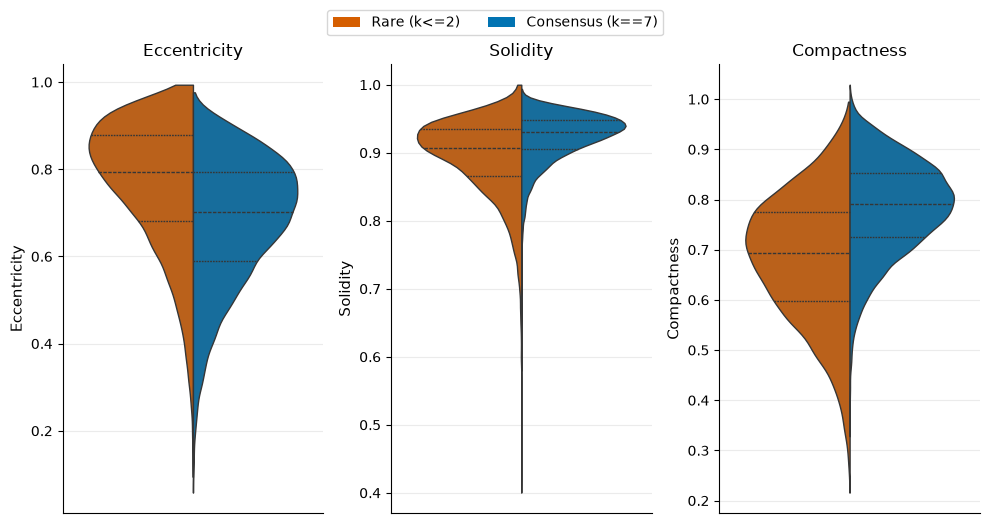

In [9]:
fig, axs = plt.subplots(1, len(SHAPES), figsize=(10, 5))
for ax, metric in zip(axs, SHAPES):
    plot_split_violin(hard, metric, ax)
    ax.set_xticks([])
    ax.set_title(metric, fontsize=12)
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize=10)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "Reviewer_Agreement_HardCellShape_Merged.pdf", bbox_inches="tight")

pooled_stats = add_holm(pd.DataFrame([{"metric": metric, **compare_buckets(hard, metric)} for metric in SHAPES]))
pooled_stats.to_csv(EXPORT_DIR / "Reviewer_Agreement_HardCellShape_Merged_stats.csv", index=False)
pooled_stats